In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
orders_df = pd.read_csv(
    "../data/synthetic/quick_commerce_orders.csv"
)

print("Dataset loaded successfully")

orders_df.head()

Dataset loaded successfully


,order_id,city,order_time,delivery_time,order_status,payment_method,order_amount,delivery_fee,discount,final_amount,delivery_minutes,order_hour,order_day,order_month,is_weekend,is_peak_hour,sla_breach
0,1,Hyderabad,2025-02-18 10:05:00,2025-02-18 10:28:00,Delivered,Cash on Delivery,1410.21,27.05,83.01,1354.25,23,10,Tuesday,February,False,True,False
1,2,Delhi,2025-02-17 14:29:00,2025-02-17 15:00:00,Delivered,Cash on Delivery,1514.24,17.65,19.65,1512.24,31,14,Monday,February,False,True,True
2,3,Pune,2025-01-27 05:02:00,2025-01-27 05:29:00,Delivered,Card,665.54,14.13,46.25,633.42,27,5,Monday,January,False,False,False
3,4,Kolkata,2025-01-26 13:08:00,2025-01-26 13:38:00,Delivered,Cash on Delivery,992.70,17.67,99.01,911.36,30,13,Sunday,January,True,True,False
4,5,Ahmedabad,2025-04-20 08:04:00,2025-04-20 08:34:00,Delivered,UPI,766.43,33.26,42.39,757.30,30,8,Sunday,April,True,True,False


# City-wise Revenue Analysis

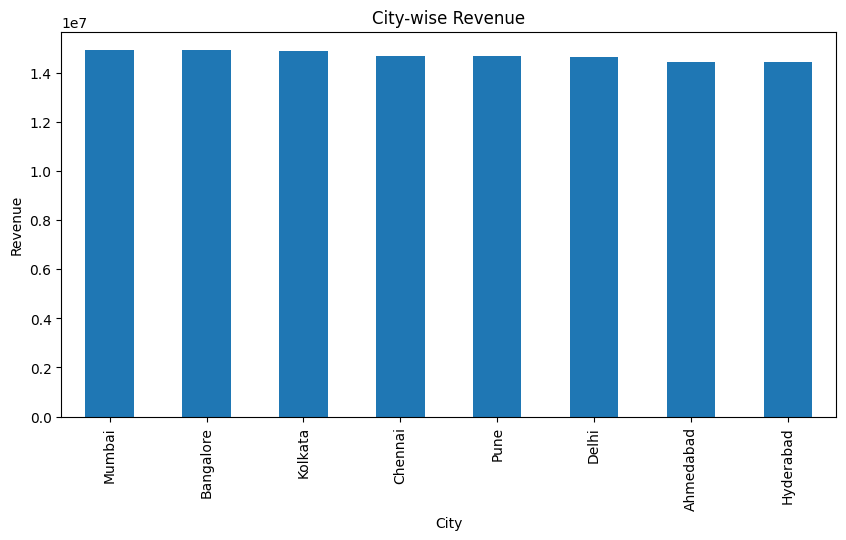

In [4]:
city_revenue = (
    orders_df
    .groupby("city")["final_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

city_revenue.plot(kind="bar")

plt.title("City-wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.show()

# Peak Hour Demand Analysis

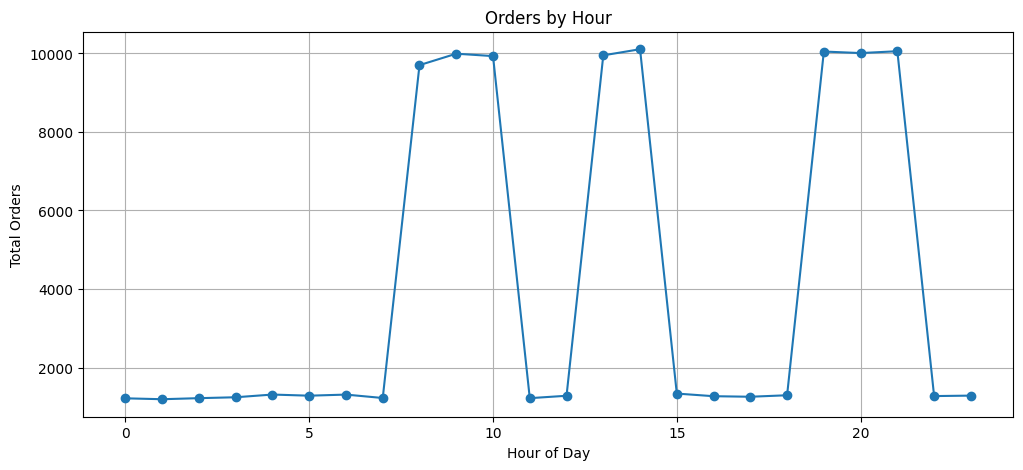

In [5]:
# Extract order hour

orders_df["order_hour"] = pd.to_datetime(
    orders_df["order_time"]
).dt.hour

# Hourly demand analysis

hourly_orders = (
    orders_df
    .groupby("order_hour")
    .size()
)

plt.figure(figsize=(12, 5))

hourly_orders.plot(kind="line", marker="o")

plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Orders")

plt.grid(True)

plt.show()

# Cancellation Analysis

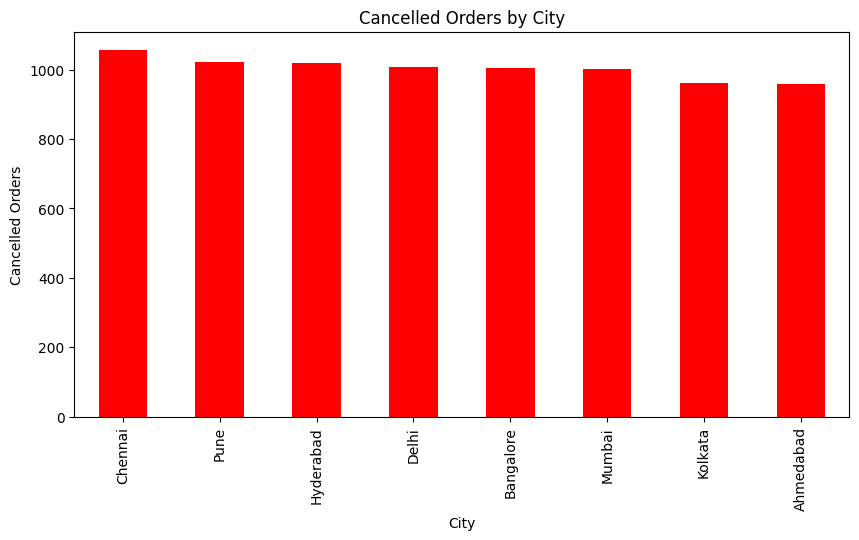

In [6]:
cancellations_by_city = (
    orders_df[orders_df["order_status"] == "Cancelled"]
    .groupby("city")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

cancellations_by_city.plot(kind="bar", color="red")

plt.title("Cancelled Orders by City")
plt.xlabel("City")
plt.ylabel("Cancelled Orders")

plt.show()

# SLA Breach Analysis

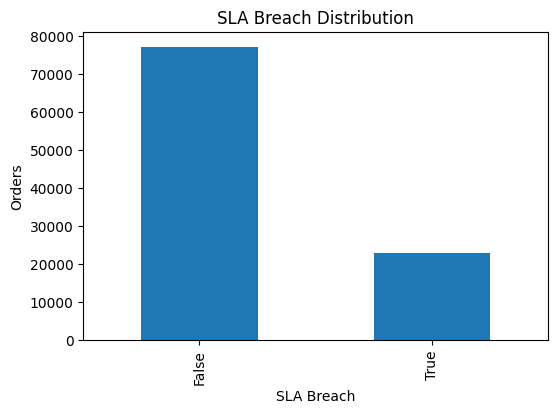

SLA Breach Rate: 22.77%


In [7]:
# SLA threshold
SLA_LIMIT = 30

# Create SLA breach column
orders_df["sla_breach"] = (
    orders_df["delivery_minutes"] > SLA_LIMIT
)

# Count breaches
sla_counts = orders_df["sla_breach"].value_counts()

plt.figure(figsize=(6, 4))

sla_counts.plot(
    kind="bar",
)

plt.title("SLA Breach Distribution")
plt.xlabel("SLA Breach")
plt.ylabel("Orders")

plt.show()

# Breach percentage
sla_breach_rate = (
    orders_df["sla_breach"]
    .mean()
) * 100

print(f"SLA Breach Rate: {sla_breach_rate:.2f}%")

# Average Delivery Time by City

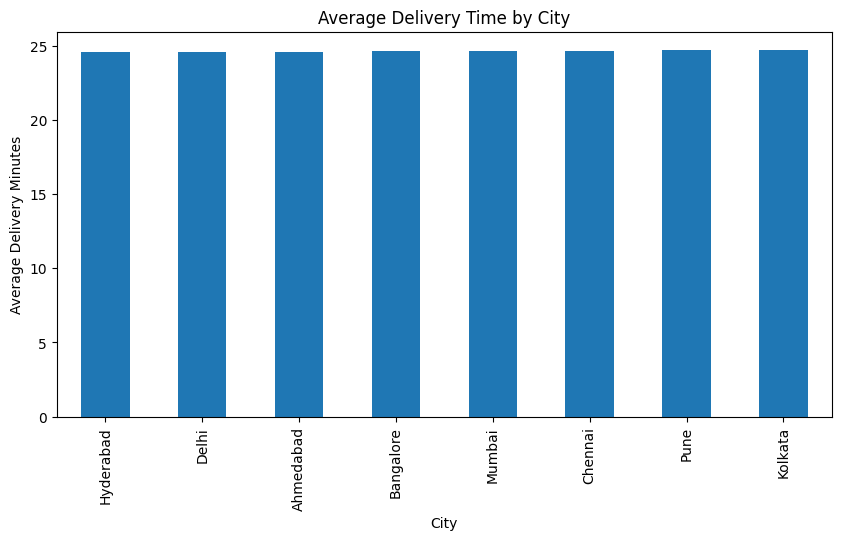

city
Hyderabad    24.576296
Delhi        24.579453
Ahmedabad    24.601164
Bangalore    24.612980
Mumbai       24.655290
Chennai      24.665492
Pune         24.708862
Kolkata      24.713423
Name: delivery_minutes, dtype: float64

In [8]:
delivery_performance = (
    orders_df
    .groupby("city")["delivery_minutes"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 5))

delivery_performance.plot(kind="bar")

plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Average Delivery Minutes")

plt.show()

delivery_performance

# Peak Hour vs SLA Breach Analysis

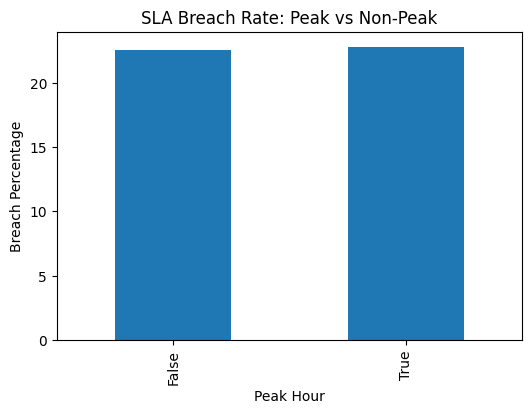

is_peak_hour
False    22.567073
True     22.816361
Name: sla_breach, dtype: float64

In [9]:
# Create peak hour flag

peak_hours = [8, 9, 10, 13, 14, 19, 20, 21]

orders_df["is_peak_hour"] = (
    orders_df["order_hour"]
    .isin(peak_hours)
)

# SLA breach comparison

peak_sla_analysis = (
    orders_df
    .groupby("is_peak_hour")["sla_breach"]
    .mean()
    * 100
)

plt.figure(figsize=(6, 4))

peak_sla_analysis.plot(kind="bar")

plt.title("SLA Breach Rate: Peak vs Non-Peak")
plt.xlabel("Peak Hour")
plt.ylabel("Breach Percentage")

plt.show()

peak_sla_analysis

# Weekday Order Analysis

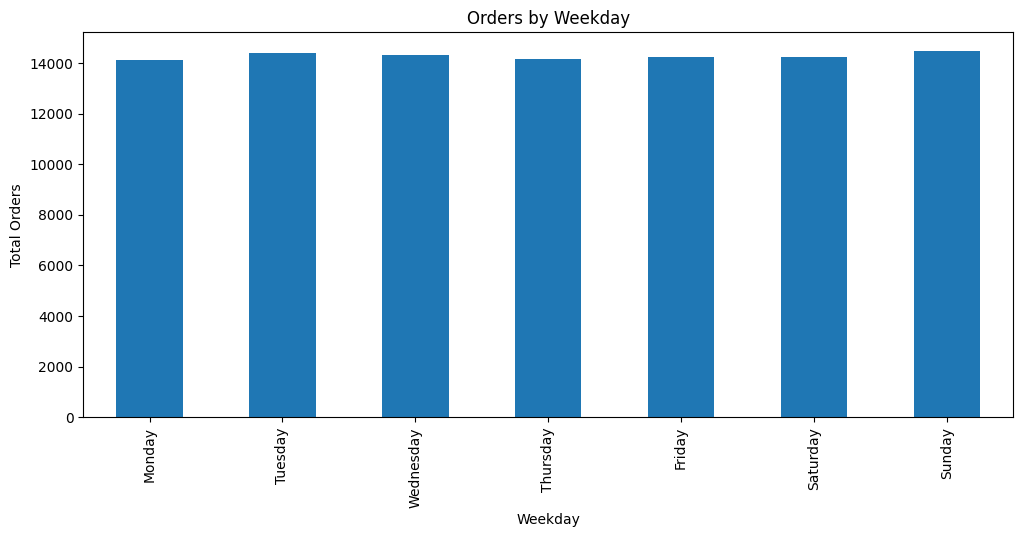

In [10]:
# Convert order_time properly

orders_df["order_time"] = pd.to_datetime(
    orders_df["order_time"]
)

# Extract weekday names

orders_df["weekday"] = (
    orders_df["order_time"]
    .dt.day_name()
)

# Weekday order counts

weekday_orders = (
    orders_df
    .groupby("weekday")
    .size()
)

# Proper weekday order

weekday_order_sequence = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_orders = weekday_orders.reindex(
    weekday_order_sequence
)

plt.figure(figsize=(12, 5))

weekday_orders.plot(kind="bar")

plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Orders")

plt.show()

# Order Value Segmentation

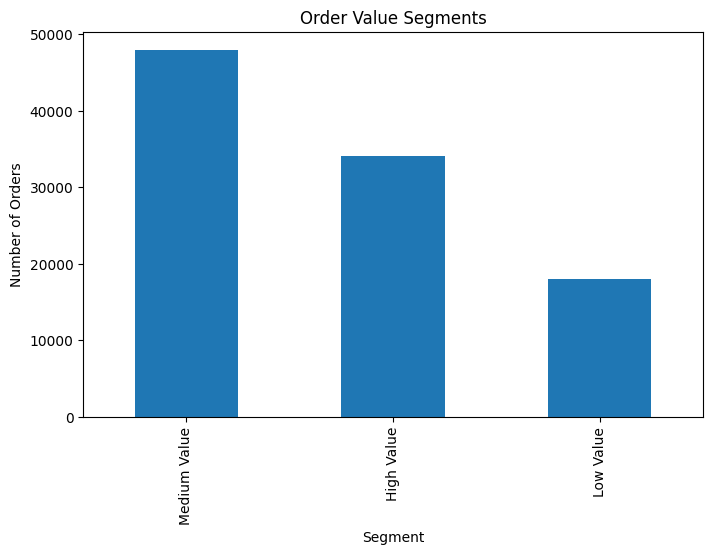

order_segment
Medium Value    47949
High Value      34092
Low Value       17959
Name: count, dtype: int64

In [11]:
# Create order segments

orders_df["order_segment"] = pd.cut(
    orders_df["final_amount"],
    bins=[0, 500, 1500, 3000],
    labels=["Low Value", "Medium Value", "High Value"]
)

# Segment distribution

segment_counts = (
    orders_df["order_segment"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

segment_counts.plot(kind="bar")

plt.title("Order Value Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Orders")

plt.show()

segment_counts

# Payment Method Analysis

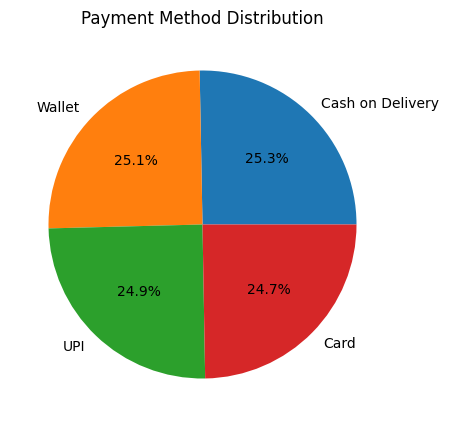

payment_method
Cash on Delivery    25295
Wallet              25110
UPI                 24871
Card                24724
Name: count, dtype: int64

In [12]:
payment_analysis = (
    orders_df["payment_method"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

payment_analysis.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.show()

payment_analysis

# Correlation Analysis

In [13]:
correlation_data = orders_df[
    [
        "order_amount",
        "delivery_fee",
        "discount",
        "final_amount",
        "delivery_minutes"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,order_amount,delivery_fee,discount,final_amount,delivery_minutes
order_amount,1.000000,0.006770,0.630204,0.984701,-0.004639
delivery_fee,0.006770,1.000000,0.008243,0.033879,0.003646
discount,0.630204,0.008243,1.000000,0.487036,-0.002775
final_amount,0.984701,0.033879,0.487036,1.000000,-0.004498
delivery_minutes,-0.004639,0.003646,-0.002775,-0.004498,1.000000


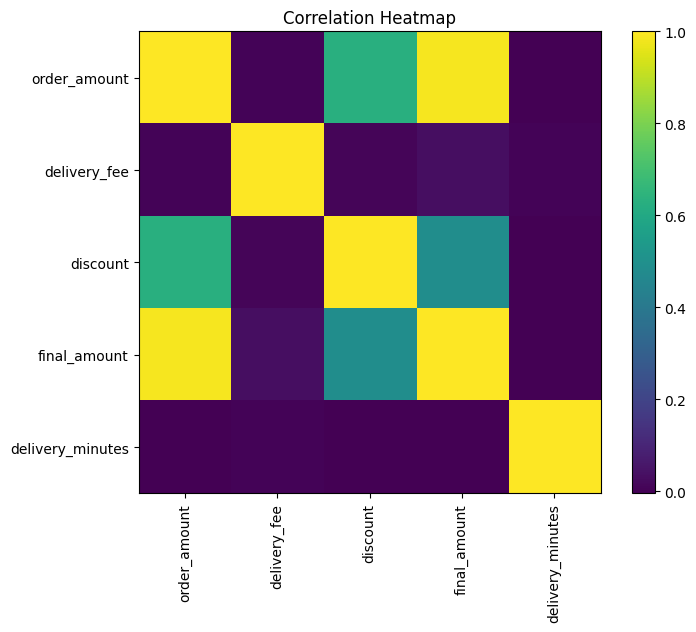

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.show()

# City vs Peak Hour Demand Analysis

In [15]:
city_peak_analysis = (
    orders_df
    .groupby(["city", "is_peak_hour"])
    .size()
    .unstack()
)

city_peak_analysis

is_peak_hour,False,True
city,,
Ahmedabad,2541,9830
Bangalore,2638,10028
Chennai,2576,9914
Delhi,2429,9962
Hyderabad,2514,9813
Kolkata,2484,10106
Mumbai,2552,10076
Pune,2468,10069


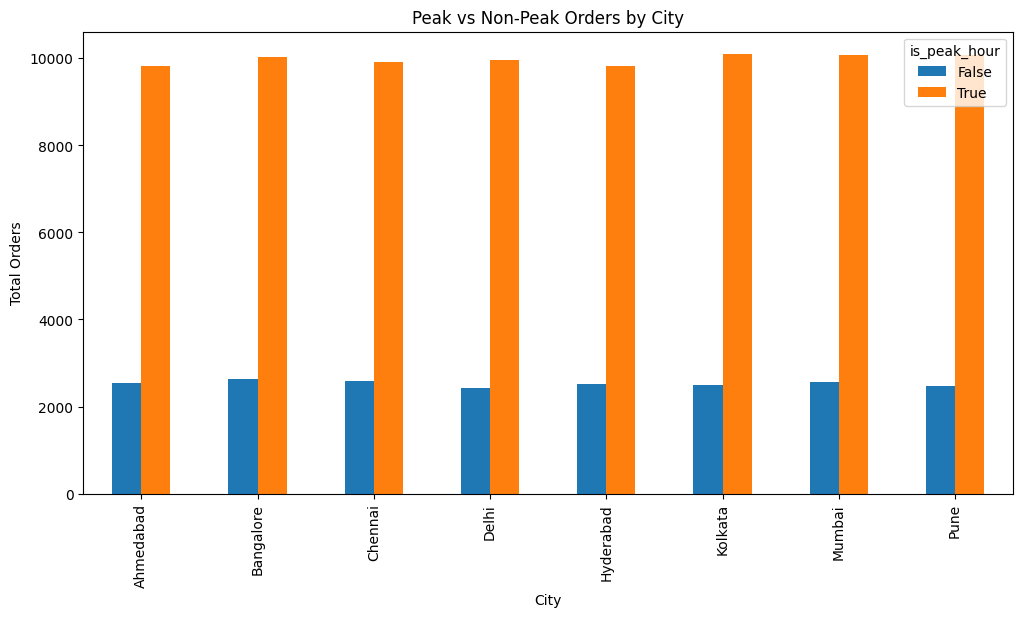

In [16]:
city_peak_analysis.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Peak vs Non-Peak Orders by City")
plt.xlabel("City")
plt.ylabel("Total Orders")

plt.show()

# City-wise SLA Breach Analysis

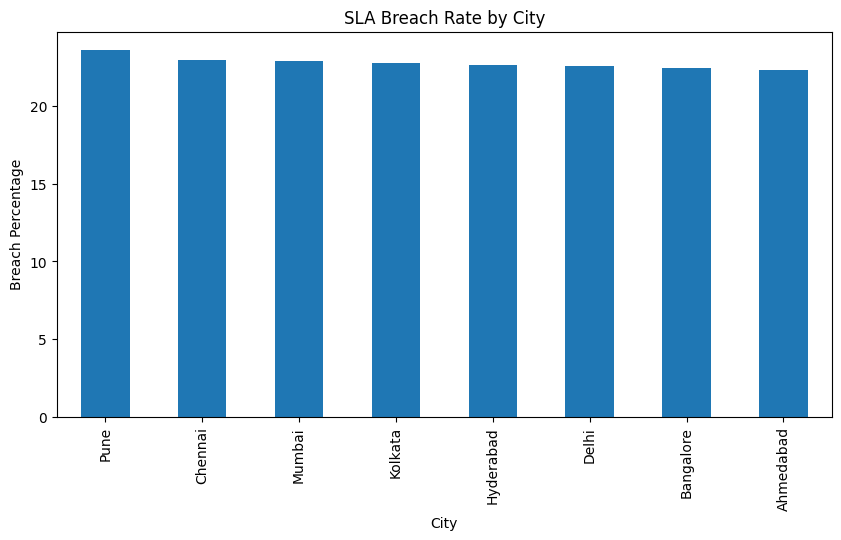

city
Pune         23.610114
Chennai      22.930344
Mumbai       22.885651
Kolkata      22.740270
Hyderabad    22.641356
Delhi        22.580905
Bangalore    22.430128
Ahmedabad    22.302158
Name: sla_breach, dtype: float64

In [17]:
city_sla_breach = (
    orders_df
    .groupby("city")["sla_breach"]
    .mean()
    * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))

city_sla_breach.plot(kind="bar")

plt.title("SLA Breach Rate by City")
plt.xlabel("City")
plt.ylabel("Breach Percentage")

plt.show()

city_sla_breach

# Executive KPI Summaryv

In [20]:
kpi_summary = pd.DataFrame({

    "Metric": [
        "Total Orders",
        "Total Revenue",
        "Average Order Value",
        "Cancellation Rate (%)",
        "SLA Breach Rate (%)",
        "Average Delivery Time"
    ],

    "Value": [

        len(orders_df),

        round(
            orders_df["final_amount"].sum(),
            2
        ),

        round(
            orders_df["final_amount"].mean(),
            2
        ),

        round(
            (
                orders_df["order_status"]
                .eq("Cancelled")
                .mean()
            ) * 100,
            2
        ),

        round(
            (
                orders_df["sla_breach"]
                .mean()
            ) * 100,
            2
        ),

        round(
            orders_df["delivery_minutes"]
            .mean(),
            2
        )

    ]
})

kpi_summary

,Metric,Value
0,Total Orders,1.000000e+05
1,Total Revenue,1.176284e+08
2,Average Order Value,1.176280e+03
3,Cancellation Rate (%),8.030000e+00
4,SLA Breach Rate (%),2.277000e+01
5,Average Delivery Time,2.464000e+01


# Daily Order Trend Analysis

In [21]:
# Convert order_time properly

orders_df["order_time"] = pd.to_datetime(
    orders_df["order_time"]
)

# Extract order date

orders_df["order_date"] = (
    orders_df["order_time"]
    .dt.date
)

# Daily orders

daily_orders = (
    orders_df
    .groupby("order_date")
    .size()
)

daily_orders.head()

order_date
2025-01-01    940
2025-01-02    891
2025-01-03    898
2025-01-04    862
2025-01-05    886
dtype: int64

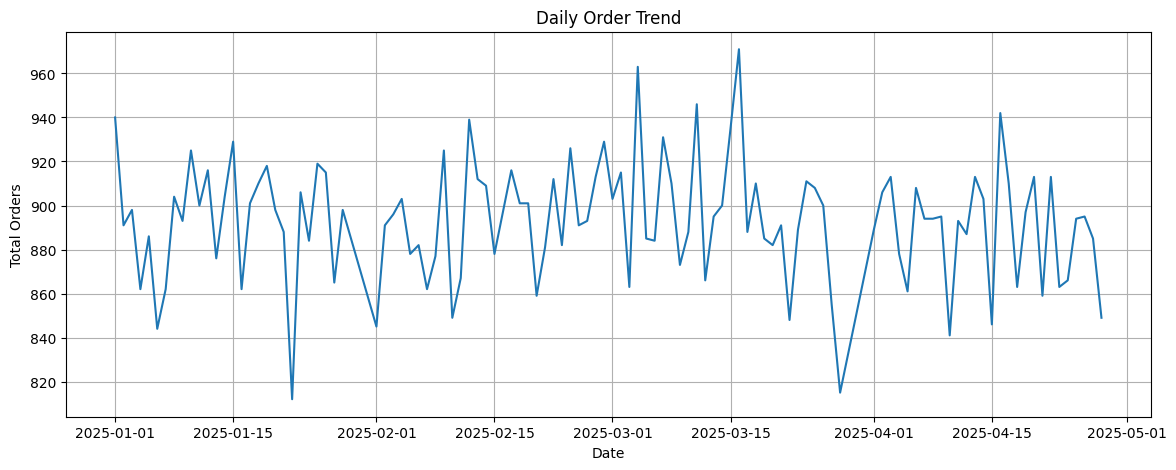

In [22]:
plt.figure(figsize=(14, 5))

daily_orders.plot()

plt.title("Daily Order Trend")
plt.xlabel("Date")
plt.ylabel("Total Orders")

plt.grid(True)

plt.show()

# Moving Average Forecasting

In [23]:
# Convert to dataframe

daily_orders_df = daily_orders.reset_index()

daily_orders_df.columns = [
    "order_date",
    "total_orders"
]

# Calculate rolling average

daily_orders_df["7_day_moving_avg"] = (
    daily_orders_df["total_orders"]
    .rolling(window=7)
    .mean()
)

daily_orders_df.head(10)

,order_date,total_orders,7_day_moving_avg
0,2025-01-01,940,NaN
1,2025-01-02,891,NaN
2,2025-01-03,898,NaN
3,2025-01-04,862,NaN
4,2025-01-05,886,NaN
5,2025-01-06,844,NaN
6,2025-01-07,862,883.285714
7,2025-01-08,904,878.142857
8,2025-01-09,893,878.428571
9,2025-01-10,925,882.285714


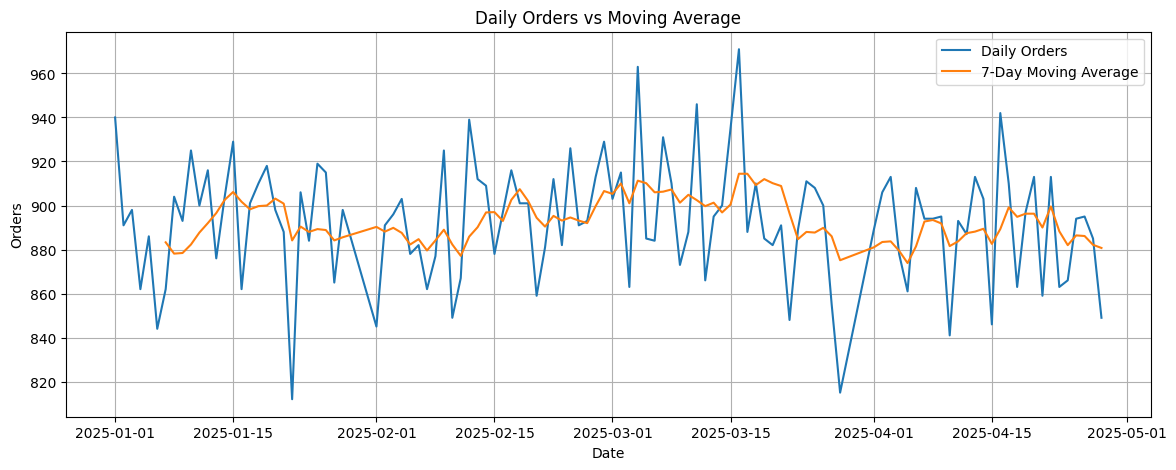

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_orders_df["order_date"],
    daily_orders_df["total_orders"],
    label="Daily Orders"
)

plt.plot(
    daily_orders_df["order_date"],
    daily_orders_df["7_day_moving_avg"],
    label="7-Day Moving Average"
)

plt.title("Daily Orders vs Moving Average")
plt.xlabel("Date")
plt.ylabel("Orders")

plt.legend()

plt.grid(True)

plt.show()

# Operational Insights & Recommendations

In [25]:
print("1. Peak-hour demand dominates operational workload.")
print("Recommendation: Increase rider allocation during breakfast, lunch, and evening hours.\n")

print("2. SLA breaches increase operational risk.")
print("Recommendation: Improve dispatch optimization and rider allocation in high-delay cities.\n")

print("3. Revenue distribution is balanced across metro cities.")
print("Recommendation: Expand dark-store inventory strategically across high-performing regions.\n")

print("4. High-value orders contribute significantly to revenue.")
print("Recommendation: Introduce loyalty and premium customer retention strategies.\n")

print("5. Delivery performance varies across operational windows.")
print("Recommendation: Deploy predictive staffing during peak demand periods.")

1. Peak-hour demand dominates operational workload.
Recommendation: Increase rider allocation during breakfast, lunch, and evening hours.

2. SLA breaches increase operational risk.
Recommendation: Improve dispatch optimization and rider allocation in high-delay cities.

3. Revenue distribution is balanced across metro cities.
Recommendation: Expand dark-store inventory strategically across high-performing regions.

4. High-value orders contribute significantly to revenue.
Recommendation: Introduce loyalty and premium customer retention strategies.

5. Delivery performance varies across operational windows.
Recommendation: Deploy predictive staffing during peak demand periods.


In [27]:
# Export analytics-ready dataset

orders_df.to_csv(
    "../exports/quick_commerce_dashboard_dataset.csv",
    index=False
)

print("Dashboard dataset exported successfully")

Dashboard dataset exported successfully
